# 03 - LSTM Forecasting Model
Long Short-Term Memory (LSTM) is a type of Recurrent Neural Network (RNN)
designed to learn patterns across time sequences.

Unlike XGBoost which sees each row independently, LSTM sees a *window* of
past timesteps and learns how the sequence evolves over time.

Key concepts:
- SEQUENCE_LENGTH: how many past days the model looks at to make one prediction
- Scaling: LSTM requires values between 0-1 (MinMaxScaler)
- GPU: training runs on RTX 2060 automatically if CUDA is available

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
import mlflow
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')
load_dotenv()

# GPU setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

DATA_PATH     = os.getenv('DATA_PATH')
EXPORTS_PATH  = os.getenv('EXPORTS_PATH')

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("ts-model-framework")

print("Libraries loaded.")

q:\scripts\projects\ts-model-framework\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Libraries loaded.


---
## S1 - Load & Scale Data
LSTM requires values scaled to 0-1 range.
Scaler is fit on training data only -- applied to test to prevent data leakage.

In [2]:
FILE_NAME     = "timeseries_with_features.csv"
DATE_COLUMN   = "date"
TARGET_COLUMN = "unit_sales"
TEST_START    = "2014-01-01"

file_path = os.path.join(DATA_PATH, FILE_NAME)
df = pd.read_csv(file_path, parse_dates=[DATE_COLUMN], index_col=DATE_COLUMN)
df = df.sort_index()

# Split
df_train = df[df.index < TEST_START][[TARGET_COLUMN]].fillna(method='ffill')
df_test  = df[df.index >= TEST_START][[TARGET_COLUMN]].fillna(method='ffill')

# Scale
scaler      = MinMaxScaler()
train_scaled = scaler.fit_transform(df_train)
test_scaled  = scaler.transform(df_test)

print(f"Train: {df_train.shape} | Test: {df_test.shape}")
print(f"Scaled range -- min: {train_scaled.min():.3f} max: {train_scaled.max():.3f}")

Train: (363, 1) | Test: (89, 1)
Scaled range -- min: 0.000 max: 1.000


---
## S2 - Build Sequences
LSTM doesn't see individual rows -- it sees sliding windows of past values.

Example with SEQUENCE_LENGTH=7:
- Input:  [day1, day2, day3, day4, day5, day6, day7]
- Target: [day8]
- Next:   [day2, day3, day4, day5, day6, day7, day8] → [day9]

In [3]:
SEQUENCE_LENGTH = 30   # days of history per prediction

def make_sequences(data, seq_length):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i - seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train_np, y_train_np = make_sequences(train_scaled, SEQUENCE_LENGTH)
X_test_np,  y_test_np  = make_sequences(test_scaled,  SEQUENCE_LENGTH)

# Reshape for PyTorch: (samples, timesteps, features)
X_train_np = X_train_np.reshape(-1, SEQUENCE_LENGTH, 1)
X_test_np  = X_test_np.reshape(-1, SEQUENCE_LENGTH, 1)

print(f"X_train: {X_train_np.shape} | y_train: {y_train_np.shape}")
print(f"X_test:  {X_test_np.shape}  | y_test:  {y_test_np.shape}")

X_train: (333, 30, 1) | y_train: (333,)
X_test:  (59, 30, 1)  | y_test:  (59,)


---
## S3 - PyTorch Dataset & DataLoader
PyTorch requires data wrapped in Tensors and fed through a DataLoader.
BATCH_SIZE controls how many sequences are processed per training step.

In [4]:
BATCH_SIZE = 32

# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train_np).to(device)
y_train_t = torch.FloatTensor(y_train_np).to(device)
X_test_t  = torch.FloatTensor(X_test_np).to(device)
y_test_t  = torch.FloatTensor(y_test_np).to(device)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches per epoch: {len(train_loader)}")
print(f"Device: {device}")

Batches per epoch: 11
Device: cuda


---
## S4 - Define LSTM Model
HIDDEN_SIZE: number of memory units in each LSTM layer
NUM_LAYERS:  how many LSTM layers stacked on top of each other
DROPOUT:     randomly disables neurons during training to prevent overfitting

In [5]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super(LSTMForecaster, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.fc(lstm_out[:, -1, :])

HIDDEN_SIZE = 64
NUM_LAYERS  = 2
DROPOUT     = 0.2
EPOCHS      = 50
LEARNING_RATE = 0.001

model     = LSTMForecaster(hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

LSTMForecaster(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Total parameters: 50,497


---
## S5 - Train the Model
Loss should decrease each epoch -- if it stops improving, training is converging.

In [6]:
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds  = model(X_batch).squeeze()
        loss   = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.6f}")

print("Training complete.")

Epoch 10/50 | Loss: 0.021902
Epoch 20/50 | Loss: 0.021405
Epoch 30/50 | Loss: 0.021568
Epoch 40/50 | Loss: 0.021078
Epoch 50/50 | Loss: 0.015780
Training complete.


---
## S6 - Evaluate & Log to MLflow

In [7]:
params = {
    "sequence_length": SEQUENCE_LENGTH,
    "hidden_size":     HIDDEN_SIZE,
    "num_layers":      NUM_LAYERS,
    "dropout":         DROPOUT,
    "epochs":          EPOCHS,
    "learning_rate":   LEARNING_RATE,
    "batch_size":      BATCH_SIZE
}

with mlflow.start_run(run_name="lstm-baseline"):
    model.eval()
    with torch.no_grad():
        preds_scaled = model(X_test_t).squeeze().cpu().numpy()

    # Inverse transform back to original scale
    preds = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
    actuals = scaler.inverse_transform(y_test_np.reshape(-1, 1)).flatten()

    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae  = mean_absolute_error(actuals, preds)
    mape = np.mean(np.abs((actuals - preds) / actuals)) * 100
    r2   = 1 - (np.sum((actuals - preds)**2) / np.sum((actuals - np.mean(actuals))**2))

    mlflow.log_params(params)
    mlflow.log_metrics({"rmse": rmse, "mae": mae, "mape": mape, "r2": r2})

    print(f"LSTM Baseline Results:")
    print(f"  RMSE: {rmse:.2f} | MAE: {mae:.2f} | MAPE: {mape:.2f}% | R²: {r2:.4f}")

LSTM Baseline Results:
  RMSE: 127.09 | MAE: 104.57 | MAPE: 28.39% | R²: 0.3224
🏃 View run lstm-baseline at: http://localhost:5000/#/experiments/2/runs/96e97452f235445f8e0f073afa60cf68
🧪 View experiment at: http://localhost:5000/#/experiments/2


---
## S7 - Training Loss & Forecast Plot

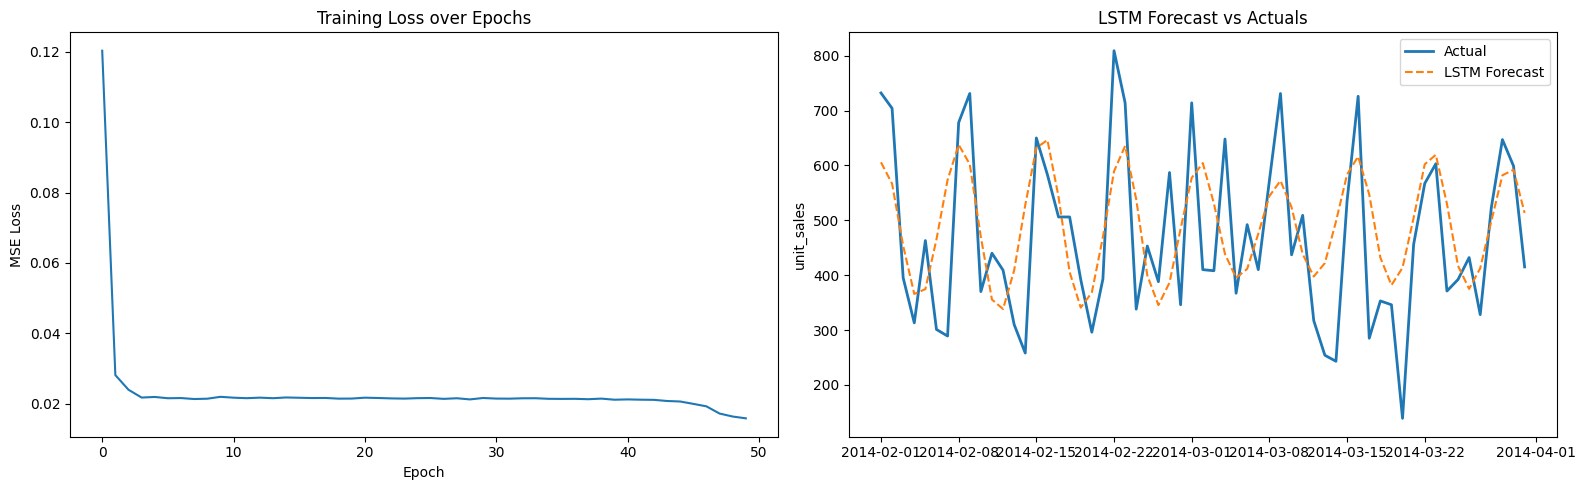

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Training loss curve
axes[0].plot(train_losses)
axes[0].set_title('Training Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')

# Forecast vs actuals
test_dates = df_test.index[SEQUENCE_LENGTH:]
axes[1].plot(test_dates, actuals, label='Actual', linewidth=2)
axes[1].plot(test_dates, preds,   label='LSTM Forecast', linestyle='--')
axes[1].set_title('LSTM Forecast vs Actuals')
axes[1].set_ylabel(TARGET_COLUMN)
axes[1].legend()

plt.tight_layout()
plt.show()

---
## S8 - Notes & Observations

- SEQUENCE_LENGTH chosen:
- Loss converged around epoch:
- RMSE vs XGBoost baseline (144.53):
- RMSE vs SARIMAX baseline (142.02):
- GPU training time approx:
- Next experiment to try: